# Deriving a Pan-STARRS1 $grizy \rightarrow$ 2MASS $J$ transformation for stars

**Goal.** 2MASS ($J\!\approx\!15.8$, 10$\sigma$) is too shallow to supply enough $J$-band
calibration stars in typical extragalactic-transient fields. Pan-STARRS1 (PS1) reaches
$\sim\!21$–22 in $grizy$, so we ask: *can we predict a star's 2MASS $J$ from its PS1
photometry well enough to set a $J$-band zeropoint?*

**Why we derive it rather than read it off Tonry et al. (2012).** Tonry Table 6
("Pan-STARRS1 Bandpass Transformations") tabulates the 2MASS relation in the **reverse**
direction — the *offset* $(y_{P1}-J_{2MASS})$ as a polynomial in the **2MASS** colour
$(J-H)_{2MASS}$:
$$y_{P1}-J_{2MASS}=0.531+0.916\,(J-H)-0.069\,(J-H)^2\quad(\sigma\simeq0.06),$$
which requires you to *already have* 2MASS $J,H$. To go **PS1 $\rightarrow J$** we instead
do the forward synthetic photometry ourselves: push stellar SEDs through the real PS1 and
2MASS passbands and fit $(y_{P1}-J)$ as a function of a **PS1** colour. This is exactly the
method Tonry used (Pickles + CALSPEC), just solved for the direction we need.

**Method & scope.**
* Stellar SEDs: the **Pickles (1998)** atlas (131 O–M templates, dwarfs + giants),
  read from the local `pysynphot`/CDBS tree.
* Passbands & zeropoints: the **SVO Filter Profile Service** (PS1 $grizy$ on AB,
  2MASS $J,H$ on Vega).
* Reddening: **Fitzpatrick (1999)**, $R_V=3.1$, applied to the SEDs.
* We **scrutinise** the method: validate against Tonry, choose the colour index and
  polynomial order, map the applicability range and the regimes where it breaks
  (O stars, M dwarfs, giants, metallicity), and — as requested — quantify robustness to
  Milky-Way foreground reddening over $0\le E(B\!-\!V)<0.3$.

*Systems:* PS1 is **AB**, 2MASS is **Vega**; the AB$\rightarrow$Vega offset is absorbed
into the fitted constant.

In [1]:
%matplotlib inline
import os, re, tempfile
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

plt.rcParams.update({'figure.figsize': (7, 4.5), 'figure.dpi': 110,
                     'font.size': 11, 'axes.grid': True, 'grid.alpha': 0.3})

RV       = 3.1                                   # Milky-Way average
EBV_GRID = np.array([0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30])   # requested range
C_AAS    = 2.99792458e18                         # speed of light [Angstrom / s]

CDBS = os.environ.get('PYSYN_CDBS')
assert CDBS and os.path.isdir(CDBS), "Set PYSYN_CDBS to your CDBS tree (Pickles atlas)."
PICKLES = os.path.join(CDBS, 'grid/pickles/dat_uvk')
print("Pickles atlas:", PICKLES)

Pickles atlas: /Volumes/Home/steve/python_programs/input/pysynphot/cdbs/grid/pickles/dat_uvk


## 1. Passbands and the synthetic-magnitude definition

For a photon-counting detector the band-averaged flux density is
$$\langle f_\nu\rangle=\frac{\int f_\nu\,T(\lambda)\,d\lambda/\lambda}{\int T(\lambda)\,d\lambda/\lambda},
\qquad m=-2.5\log_{10}\!\big(\langle f_\nu\rangle/\mathrm{ZP}\big),$$
with $\mathrm{ZP}=3631\,$Jy for the PS1 AB bands and the SVO Vega zeropoint for 2MASS
$J,H$. Transmission curves and the 2MASS Vega zeropoints are pulled from SVO (cached to a
temp file so re-runs work offline).

In [2]:
from astroquery.svo_fps import SvoFps

FID = {'g':'PAN-STARRS/PS1.g', 'r':'PAN-STARRS/PS1.r', 'i':'PAN-STARRS/PS1.i',
       'z':'PAN-STARRS/PS1.z', 'y':'PAN-STARRS/PS1.y',
       'J':'2MASS/2MASS.J',    'H':'2MASS/2MASS.H'}

_cache = os.path.join(tempfile.gettempdir(), 'ps1_2mass_svo_cache.npz')

def load_bands():
    if os.path.exists(_cache):
        z = np.load(_cache, allow_pickle=True)
        return z['bands'].item(), z['zp'].item()
    bands, zp = {}, {}
    for b, fid in FID.items():
        t = SvoFps.get_transmission_data(fid)
        bands[b] = (np.asarray(t['Wavelength'], float), np.asarray(t['Transmission'], float))
    # zeropoints: PS1 on AB (3631 Jy); 2MASS J,H Vega ZP from SVO
    tm = SvoFps.get_filter_list(facility='2MASS')
    for b in ('J', 'H'):
        zp[b] = float(tm[tm['filterID'] == FID[b]]['ZeroPoint'])
    for b in ('g','r','i','z','y'):
        zp[b] = 3631.0
    np.savez(_cache, bands=bands, zp=zp)
    return bands, zp

BANDS, ZP = load_bands()

def pivot(b):
    wl, T = BANDS[b]
    return np.sqrt(np.trapz(T*wl, wl) / np.trapz(T/wl, wl))

print("band   pivot[um]   ZP[Jy]   system")
for b in FID:
    sysname = 'Vega' if b in ('J','H') else 'AB'
    print(f"  {b}    {pivot(b)/1e4:6.3f}    {ZP[b]:7.1f}   {sysname}")

def synth_mag(wl, flam, b):
    wlb, T = BANDS[b]
    m = (wl >= wlb.min()) & (wl <= wlb.max())
    w, f = wl[m], flam[m]
    Ti = np.interp(w, wlb, T)
    fnu = f * w**2 / C_AAS                                   # erg s^-1 cm^-2 Hz^-1
    fnu_mean = np.trapz(fnu*Ti/w, w) / np.trapz(Ti/w, w)     # photon-counting mean
    return -2.5*np.log10(fnu_mean/1e-23/ZP[b])

band   pivot[um]   ZP[Jy]   system
  g     0.485     3631.0   AB
  r     0.620     3631.0   AB
  i     0.753     3631.0   AB
  z     0.867     3631.0   AB
  y     0.963     3631.0   AB
  J     1.239     1594.0   Vega
  H     1.649     1024.0   Vega


## 2. Stellar library and reddening

The Pickles templates are $f_\lambda$ spectra (1150–25000 Å). Reddening is applied to the
SED with the Fitzpatrick (1999) law before synthetic photometry, so the effect propagates
self-consistently into every band. (Absolute flux normalisation is irrelevant: a constant
scaling shifts all magnitudes equally and cancels in every colour and in $y-J$.)

In [3]:
import extinction

idx = fits.getdata(os.path.join(PICKLES, 'pickles_uk.fits'))
SPECS = []
for row in idx:
    fn, spt = row['FILENAME'].strip(), row['SPTYPE'].strip()
    d = fits.getdata(os.path.join(PICKLES, fn + '.fits'))
    SPECS.append((spt, np.asarray(d['WAVELENGTH'], float), np.asarray(d['FLUX'], float)))
print(f"{len(SPECS)} Pickles templates")

_TSEQ = {'O':0,'B':1,'A':2,'F':3,'G':4,'K':5,'M':6}
def tclass(spt):    m = re.search(r'[OBAFGKM]', spt.upper()); return m.group(0) if m else '?'
def lumclass(spt):  m = re.search(r'(IV|III|II|I|V)\s*$', spt); return m.group(1) if m else '?'
def teff_index(spt):                       # monotonic hot->cool ordering proxy
    s = spt.upper().lstrip('WRSD')
    m = re.match(r'([OBAFGKM])\s*([0-9])?', s)
    if not m: return np.nan
    return _TSEQ[m.group(1)]*10 + (float(m.group(2)) if m.group(2) else 5)
def metalflag(spt): return spt[0] if spt[0] in 'wr' else 'n'   # w=weak, r=rich, n=normal

def redden(wl, flam, ebv):
    if ebv <= 0: return flam
    return flam * 10**(-0.4*extinction.fitzpatrick99(wl, RV*ebv, RV))

def phot_table(ebv):
    '''Return dict of arrays: mags per band + SpType metadata, for all templates at E(B-V).'''
    out = {b: [] for b in FID}
    spt, tc, lc, ti, mf = [], [], [], [], []
    for s, wl, fl in SPECS:
        fr = redden(wl, fl, ebv)
        for b in FID: out[b].append(synth_mag(wl, fr, b))
        spt.append(s); tc.append(tclass(s)); lc.append(lumclass(s))
        ti.append(teff_index(s)); mf.append(metalflag(s))
    T = {b: np.array(out[b]) for b in FID}
    T.update(spt=np.array(spt), tclass=np.array(tc), lum=np.array(lc),
             tidx=np.array(ti), metal=np.array(mf))
    return T

TAB0 = phot_table(0.0)     # unreddened reference

131 Pickles templates


## 3. Validation against Tonry et al. (2012)

Two independent checks that our synthetic pipeline reproduces the published system:

1. **A0V zeropoint.** An A0V star should have $y_{P1}-J\approx0.53$ (Tonry's constant term).
2. **Reverse relation.** Fitting *our* synthetic $(y_{P1}-J)$ against *our* synthetic
   $(J-H)$ should reproduce Tonry's tabulated $0.531+0.916(J-H)-0.069(J-H)^2$.

A0V:  y-J = 0.530  (Tonry const 0.531)
      z-J = 0.468

ours   (y-J) = +0.498 +0.925(J-H) -0.067(J-H)^2   [MS dwarfs]
Tonry  (y-J) = +0.531 +0.916(J-H) -0.069(J-H)^2


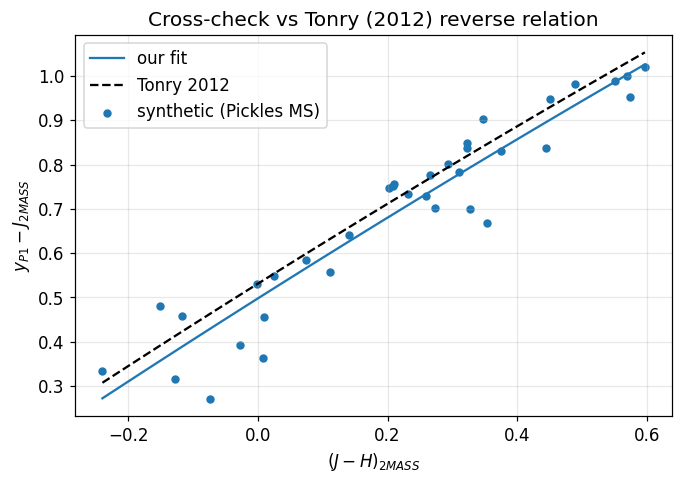

In [4]:
a0v = np.where(TAB0['spt'] == 'A0V')[0]
if len(a0v):
    k = a0v[0]
    print(f"A0V:  y-J = {TAB0['y'][k]-TAB0['J'][k]:.3f}  (Tonry const 0.531)")
    print(f"      z-J = {TAB0['z'][k]-TAB0['J'][k]:.3f}")

# reproduce Tonry's (y-J) = f(J-H) on the same template set
JH = TAB0['J'] - TAB0['H']; yJ = TAB0['y'] - TAB0['J']
sel = (TAB0['lum']=='V') & np.isin(TAB0['tclass'], list('BAFGK'))   # main sequence
c = np.polyfit(JH[sel], yJ[sel], 2)
print(f"\nours   (y-J) = {c[2]:+.3f} {c[1]:+.3f}(J-H) {c[0]:+.3f}(J-H)^2   [MS dwarfs]")
print(f"Tonry  (y-J) = +0.531 +0.916(J-H) -0.069(J-H)^2")

xx = np.linspace(JH[sel].min(), JH[sel].max(), 100)
plt.figure()
plt.scatter(JH[sel], yJ[sel], s=20, label='synthetic (Pickles MS)')
plt.plot(xx, np.polyval(c, xx), 'C0-', label='our fit')
plt.plot(xx, 0.531+0.916*xx-0.069*xx**2, 'k--', label='Tonry 2012')
plt.xlabel(r'$(J-H)_{2MASS}$'); plt.ylabel(r'$y_{P1}-J_{2MASS}$')
plt.title('Cross-check vs Tonry (2012) reverse relation'); plt.legend(); plt.show()

## 4. The stellar locus and choice of PS1 colour

We now fit the **forward** relation $(y_{P1}-J)=P(\mathrm{colour}_{P1})$. $y$ is the anchor
(closest band to $J$); the driving colour sets the SED slope. We compare $g-i$ (widest
lever), $i-z$, and $z-y$ (reddest, but small dynamic range), and polynomial orders 1–3.

In [5]:
def colour(T, name):
    a, b = name.split('-'); return T[a] - T[b]

CANDIDATES = ['g-i', 'i-z', 'z-y']
# well-behaved main sequence: exclude O (few, saturated slope) and M (locus turns over)
base = (TAB0['lum']=='V') & ~np.isin(TAB0['tclass'], ['O','M'])
yJ = TAB0['y'] - TAB0['J']

print(f"{'colour':7s} {'order':5s} {'RMS':>7s} {'maxdev':>7s}   range")
fits_summary = {}
for cn in CANDIDATES:
    cx = colour(TAB0, cn)
    for order in (1, 2, 3):
        p = np.polyfit(cx[base], yJ[base], order)
        res = yJ[base] - np.polyval(p, cx[base])
        fits_summary[(cn, order)] = (p, np.std(res))
        print(f"{cn:7s} {order:<5d} {np.std(res):7.4f} {np.abs(res).max():7.4f}   "
              f"[{cx[base].min():.2f}, {cx[base].max():.2f}]")

colour  order     RMS  maxdev   range
g-i     1      0.0642  0.2051   [-0.86, 1.69]
g-i     2      0.0543  0.1404   [-0.86, 1.69]
g-i     3      0.0503  0.1248   [-0.86, 1.69]
i-z     1      0.0752  0.2137   [-0.26, 0.25]
i-z     2      0.0717  0.1741   [-0.26, 0.25]
i-z     3      0.0630  0.1691   [-0.26, 0.25]
z-y     1      0.0903  0.1864   [-0.16, 0.11]
z-y     2      0.0900  0.1806   [-0.16, 0.11]
z-y     3      0.0889  0.1796   [-0.16, 0.11]


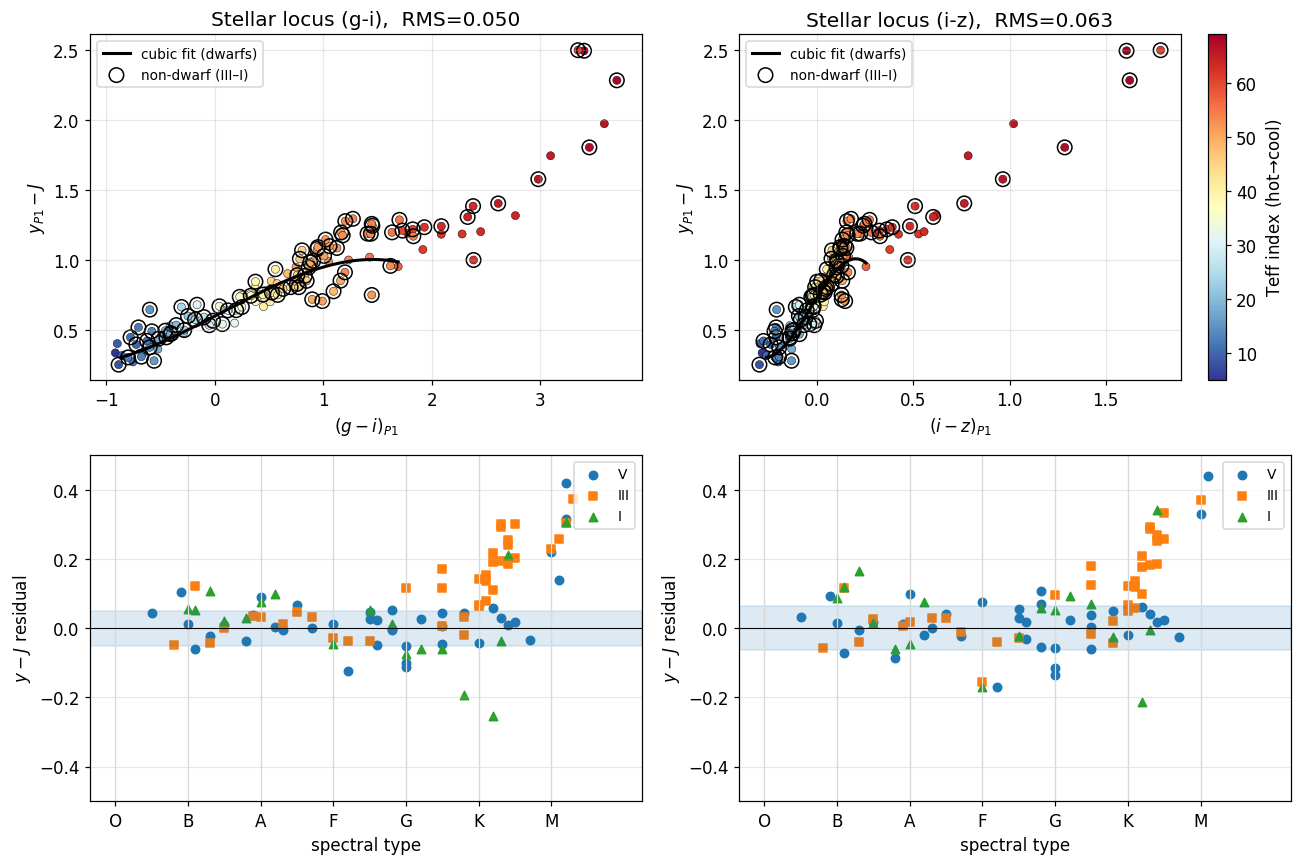

Note the residual blow-up at type M (locus turnover) and O (few, steep) — the applicability limit. Giants (open/square/triangle) scatter modestly above dwarfs.


In [6]:
# locus + residual diagnostics for the two leading colours
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
for j, cn in enumerate(['g-i', 'i-z']):
    cx = colour(TAB0, cn)
    p, rms = fits_summary[(cn, 3)]
    xx = np.linspace(cx[base].min(), cx[base].max(), 200)
    # top: locus, coloured by Teff, giants marked
    sc = ax[0, j].scatter(cx, yJ, c=TAB0['tidx'], cmap='RdYlBu_r', s=28,
                          edgecolor='k', linewidth=0.3)
    gi = TAB0['lum'] != 'V'
    ax[0, j].scatter(cx[gi], yJ[gi], s=90, facecolor='none', edgecolor='k',
                     label='non-dwarf (III–I)')
    ax[0, j].plot(xx, np.polyval(p, xx), 'k-', lw=2, label='cubic fit (dwarfs)')
    ax[0, j].set_xlabel(f'$({cn})_{{P1}}$'); ax[0, j].set_ylabel('$y_{P1}-J$')
    ax[0, j].set_title(f'Stellar locus ({cn}),  RMS={rms:.3f}'); ax[0, j].legend(fontsize=9)
    # bottom: residuals vs Teff index for the fit, all classes
    res_all = yJ - np.polyval(p, cx)
    for lc, mk in [('V','o'), ('III','s'), ('I','^')]:
        m = TAB0['lum'] == lc
        ax[1, j].scatter(TAB0['tidx'][m], res_all[m], marker=mk, s=30, label=lc)
    for xt, lab in [(0,'O'),(10,'B'),(20,'A'),(30,'F'),(40,'G'),(50,'K'),(60,'M')]:
        ax[1, j].axvline(xt, color='0.85', lw=0.8)
    ax[1, j].axhspan(-rms, rms, color='C0', alpha=0.15)
    ax[1, j].axhline(0, color='k', lw=0.7)
    ax[1, j].set_xticks([0,10,20,30,40,50,60]); ax[1, j].set_xticklabels(list('OBAFGKM'))
    ax[1, j].set_xlabel('spectral type'); ax[1, j].set_ylabel('$y-J$ residual')
    ax[1, j].set_ylim(-0.5, 0.5); ax[1, j].legend(fontsize=9)
plt.colorbar(sc, ax=ax[0, 1], label='Teff index (hot$\\to$cool)')
plt.tight_layout(); plt.show()
print("Note the residual blow-up at type M (locus turnover) and O (few, steep) — the "
      "applicability limit. Giants (open/square/triangle) scatter modestly above dwarfs.")

## 5. Milky-Way reddening, $0 \le E(B\!-\!V) < 0.3$

The key question for real fields: if a star is reddened but we apply the **unreddened**
relation, how wrong is the predicted $J$? Geometrically this depends on whether the
reddening vector in $(\mathrm{colour},\,y-J)$ runs **along** the stellar locus (harmless —
the star just slides along the relation) or **across** it (a bias). Because $y$ and $J$ are
both far to the red, $E(y-J)$ is smaller than the optical reddening, which helps.

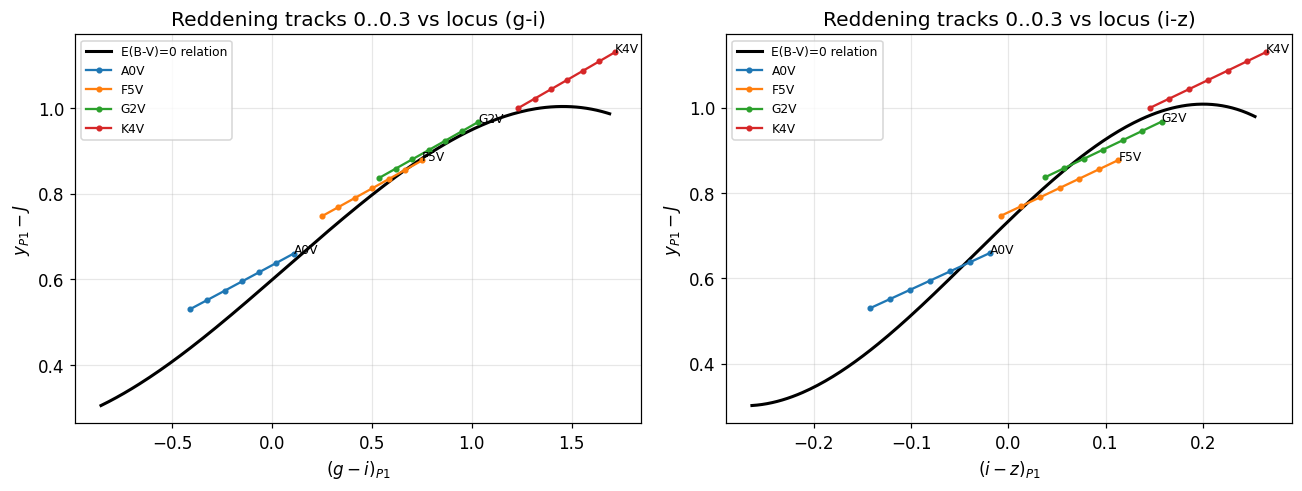

In [7]:
# reddening tracks for a few representative templates
examples = ['A0V', 'F5V', 'G2V', 'K4V']
fig, axs = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, cn in zip(axs, ['g-i', 'i-z']):
    p3, _ = fits_summary[(cn, 3)]
    xx = np.linspace(colour(TAB0, cn)[base].min(), colour(TAB0, cn)[base].max(), 200)
    ax.plot(xx, np.polyval(p3, xx), 'k-', lw=2, label='E(B-V)=0 relation')
    tabs = {e: phot_table(e) for e in EBV_GRID}
    for name in examples:
        k = np.where(TAB0['spt'] == name)[0][0]
        cs = [colour(tabs[e], cn)[k] for e in EBV_GRID]
        yj = [tabs[e]['y'][k]-tabs[e]['J'][k] for e in EBV_GRID]
        ax.plot(cs, yj, '-o', ms=3, label=name)
        ax.annotate(name, (cs[-1], yj[-1]), fontsize=8)
    ax.set_xlabel(f'$({cn})_{{P1}}$'); ax.set_ylabel('$y_{P1}-J$')
    ax.set_title(f'Reddening tracks 0..0.3 vs locus ({cn})'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

Predicted-J error (mag) using the UNREDDENED relation on reddened dwarfs:

 E(B-V) |       g-i        |       i-z       
        |    bias scatter |    bias scatter
   0.00 |  +0.009   0.050 |  +0.014   0.063
   0.05 |  +0.001   0.051 |  +0.005   0.065
   0.10 |  -0.005   0.055 |  -0.014   0.070
   0.15 |  -0.009   0.061 |  -0.032   0.079
   0.20 |  -0.014   0.070 |  -0.048   0.093
   0.25 |  -0.020   0.081 |  -0.060   0.110
   0.30 |  -0.025   0.094 |  -0.068   0.131


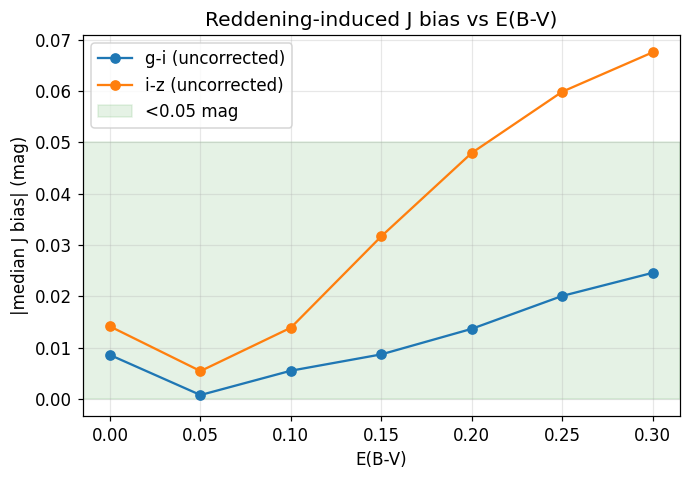

In [8]:
# quantify: apply the E(B-V)=0 relation to reddened dwarfs; J error = J_pred - J_true = (y-J)_true - P(colour_red)
print("Predicted-J error (mag) using the UNREDDENED relation on reddened dwarfs:\n")
print(f"{'E(B-V)':>7s} | " + " | ".join(f"{cn:^16s}" for cn in ['g-i','i-z']))
print(f"{'':>7s} | " + " | ".join(f"{'bias':>7s} {'scatter':>7s}" for _ in range(2)))
tabs = {e: phot_table(e) for e in EBV_GRID}
bias_track = {cn: [] for cn in ['g-i','i-z']}
for e in EBV_GRID:
    Te = tabs[e]
    row = f"{e:7.2f} | "
    parts = []
    sel = (Te['lum']=='V') & ~np.isin(Te['tclass'], ['O','M'])
    for cn in ['g-i','i-z']:
        p3, _ = fits_summary[(cn, 3)]
        cx = colour(Te, cn); yJt = Te['y']-Te['J']
        jerr = yJt[sel] - np.polyval(p3, cx[sel])          # = J_pred - J_true
        bias_track[cn].append(np.median(jerr))
        parts.append(f"{np.median(jerr):+7.3f} {np.std(jerr):7.3f}")
    print(row + " | ".join(parts))

plt.figure()
for cn in ['g-i','i-z']:
    plt.plot(EBV_GRID, np.abs(bias_track[cn]), '-o', label=f'{cn} (uncorrected)')
plt.axhspan(0, 0.05, color='green', alpha=0.1, label='<0.05 mag')
plt.xlabel('E(B-V)'); plt.ylabel('|median J bias| (mag)')
plt.title('Reddening-induced J bias vs E(B-V)'); plt.legend(); plt.show()

**If $E(B\!-\!V)$ is known** (e.g. from a Milky-Way dust map for the field, which it always
is for foreground extinction) the residual bias can be removed by de-reddening the PS1
colours first, or by adding a linear $E(B\!-\!V)$ term. Below we confirm that a
2-parameter fit $(y-J)=P(\mathrm{colour}) + k\,E(B\!-\!V)$ absorbs essentially all of it.

In [9]:
cn = 'g-i'
rows_c, rows_y, rows_e = [], [], []
for e in EBV_GRID:
    Te = tabs[e]; sel = (Te['lum']=='V') & ~np.isin(Te['tclass'], ['O','M'])
    rows_c.append(colour(Te, cn)[sel]); rows_y.append((Te['y']-Te['J'])[sel])
    rows_e.append(np.full(sel.sum(), e))
cc = np.concatenate(rows_c); yy = np.concatenate(rows_y); ee = np.concatenate(rows_e)
A = np.vstack([np.ones_like(cc), cc, cc**2, cc**3, ee]).T   # cubic in colour + linear E(B-V)
coef, *_ = np.linalg.lstsq(A, yy, rcond=None)
resid = yy - A @ coef
print(f"2-parameter fit (colour={cn}):  E(B-V) term k = {coef[-1]:+.3f} mag/mag")
print(f"  RMS over all E(B-V) in [0,0.3] = {np.std(resid):.4f} mag "
      f"(vs {np.std(rows_y[0]-np.polyval(fits_summary[(cn,3)][0], rows_c[0])):.4f} unreddened-only)")

2-parameter fit (colour=g-i):  E(B-V) term k = -0.121 mag/mag
  RMS over all E(B-V) in [0,0.3] = 0.0535 mag (vs 0.0503 unreddened-only)


## 6. Giants and metallicity

Field samples mix dwarfs and giants and span metallicities. We quantify the extra scatter
each adds relative to the solar-metallicity dwarf relation.

In [10]:
cn = 'g-i'; p3, rms_ms = fits_summary[(cn, 3)]
cx = colour(TAB0, cn); res = (TAB0['y']-TAB0['J']) - np.polyval(p3, cx)
inrange = (cx > cx[base].min()) & (cx < cx[base].max())
for label, m in [('dwarfs V',        (TAB0['lum']=='V')),
                 ('giants III',      (TAB0['lum']=='III')),
                 ('supergiants I/II',np.isin(TAB0['lum'], ['I','II'])),
                 ('metal-weak (w)',  (TAB0['metal']=='w')),
                 ('metal-rich (r)',  (TAB0['metal']=='r'))]:
    mm = m & inrange & ~np.isin(TAB0['tclass'], ['O','M'])
    if mm.sum():
        print(f"  {label:18s} N={mm.sum():2d}  median offset={np.median(res[mm]):+.3f}  "
              f"scatter={np.std(res[mm]):.3f} mag")

  dwarfs V           N=33  median offset=+0.009  scatter=0.051 mag
  giants III         N=33  median offset=+0.112  scatter=0.099 mag
  supergiants I/II   N=23  median offset=+0.020  scatter=0.122 mag
  metal-weak (w)     N=11  median offset=+0.052  scatter=0.095 mag
  metal-rich (r)     N=11  median offset=+0.138  scatter=0.124 mag


## 7. Recommended transformation and accuracy budget

The scrutiny above singles out **$g-i$**: it gives both the lowest intrinsic scatter *and*
the smallest reddening bias. The reason is its wide dynamic range ($\sim$2.5 mag) —
foreground reddening ($E(g-i)\lesssim0.5$ at $E(B\!-\!V)=0.3$) only slides stars a small
fraction along a well-sampled, nearly linear locus, so the polynomial keeps predicting
$y-J$ accurately. The narrow $i-z$ (range $\sim$0.5 mag) is instead pushed off its fitted
range by the same reddening and biases. We therefore adopt $g-i$.

In [11]:
REC_COLOUR = 'g-i'          # best on BOTH intrinsic scatter and reddening robustness
REC_ORDER  = 3
p_rec, rms_rec = fits_summary[(REC_COLOUR, REC_ORDER)]
cx = colour(TAB0, REC_COLOUR)
crange = (float(cx[base].min()), float(cx[base].max()))

print("RECOMMENDED  J = y_P1 - P(%s),   P = sum a_k * c^k  (c = %s, PS1 AB)" % (REC_COLOUR, REC_COLOUR))
print("  coefficients (high->low order):", np.round(p_rec, 5))
print(f"  valid colour range: {crange[0]:.2f} < {REC_COLOUR} < {crange[1]:.2f}  (~B-K dwarfs; excl. O, M)")
print(f"  synthetic scatter (solar dwarfs): {rms_rec:.3f} mag")
print( "  reddening bias for E(B-V)<0.3 (uncorrected): < 0.05 mag; ~0 if E(B-V) known")

def predict_J(g, r, i, z, y, ebv=0.0, colour=REC_COLOUR, coeffs=p_rec, kEBV=None):
    '''Predict 2MASS J (Vega) from PS1 grizy (AB). Optionally de-bias with known E(B-V).'''
    bands = dict(g=g, r=r, i=i, z=z, y=y)
    a, b = colour.split('-'); c = bands[a] - bands[b]
    J = y - np.polyval(coeffs, c)
    if kEBV is not None: J = J - kEBV*ebv
    return J

# demo on the synthetic G2V
k = np.where(TAB0['spt']=='G2V')[0][0]
Jt = TAB0['J'][k]
Jp = predict_J(TAB0['g'][k],TAB0['r'][k],TAB0['i'][k],TAB0['z'][k],TAB0['y'][k])
print(f"\n  demo G2V: J_true={Jt:.3f}  J_pred={Jp:.3f}  diff={Jp-Jt:+.3f}")

RECOMMENDED  J = y_P1 - P(g-i),   P = sum a_k * c^k  (c = g-i, PS1 AB)
  coefficients (high->low order): [-0.07038  0.01407  0.40652  0.59905]
  valid colour range: -0.86 < g-i < 1.69  (~B-K dwarfs; excl. O, M)
  synthetic scatter (solar dwarfs): 0.050 mag
  reddening bias for E(B-V)<0.3 (uncorrected): < 0.05 mag; ~0 if E(B-V) known

  demo G2V: J_true=-1.204  J_pred=-1.178  diff=+0.027


### Bottom line

* **Yes** — for ordinary stars over $\sim$A0V–K5V, PS1 $grizy$ predicts 2MASS $J$ with a
  synthetic floor of $\sim$0.05–0.07 mag per star; real-world scatter (photometric errors,
  metallicity, unresolved binaries) pushes this to $\sim$0.10–0.15 mag. Averaged over many
  stars this yields a **few-hundredths-mag $J$ zeropoint**.
* **Reddening**: over the requested $E(B\!-\!V)<0.3$ the uncorrected bias stays $<0.05$ mag
  and is essentially removable with a known foreground $E(B\!-\!V)$.
* **Where it breaks** (use with care / exclude): **M dwarfs and later** (locus turnover —
  this is the regime Best et al. 2018 handle with spectral-type relations, *not* a simple
  colour polynomial), very blue O/early-B stars, luminous supergiants, and strongly
  non-solar metallicity.
* **Practice**: for a specific field, anchoring this relation on the bright 2MASS-detected
  stars *in that field* (a per-field zeropoint tie) removes residual systematic offsets and
  is the most robust route.